In [20]:
# Set required environment variables for Azure OpenAI
import os
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://ducksat.cognitiveservices.azure.com/openai/deployments/gpt-5-nano/chat/completions?api-version=2025-01-01-preview"
os.environ["AZURE_OPENAI_API_KEY"] = "CKKtDWZjp3uujnxsx9mO4D2pafqAgxXnMy7vCSdaDDvEShCJhRm6JQQJ99CBACYeBjFXJ3w3AAAAACOGzRJb"
os.environ["AZURE_OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["AZURE_OPENAI_DEPLOYMENT"] = "gpt-5-nano"


In [14]:
# Import load_dotenv for environment variable loading
from dotenv import load_dotenv
import os
load_dotenv()

False

In [15]:
# Ensure python-dotenv is installed
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Install required packages (manual install recommended)
# import subprocess
# import sys
# packages = ['openai', 'python-dotenv', 'requests', 'pillow', 'matplotlib', 'numpy', 'shapely']
# for package in packages:
#     try:
#         __import__(package.replace('-', '_'))
#     except ImportError:
#         print(f"Installing {package}...")
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', package])

# Import libraries
import os
import json
import requests
import base64
from io import BytesIO
from openai import AzureOpenAI
from dotenv import load_dotenv
from IPython.display import HTML, display
load_dotenv()


False

In [19]:
# Load environment variables and configure Azure OpenAI client
load_dotenv()

endpoint = os.getenv("ENDPOINT_URL") or os.getenv("AZURE_OPENAI_ENDPOINT")
api_key = os.getenv("AZURE_OPENAI_API_KEY")
deployment_name = os.getenv("DEPLOYMENT_NAME") or os.getenv("AZURE_OPENAI_DEPLOYMENT")

missing = [
    ("ENDPOINT_URL or AZURE_OPENAI_ENDPOINT", endpoint),
    ("AZURE_OPENAI_API_KEY", api_key),
    ("DEPLOYMENT_NAME or AZURE_OPENAI_DEPLOYMENT", deployment_name)
 ]
missing = [name for name, value in missing if not value]

if missing:
    missing_str = ", ".join(missing)
    raise RuntimeError(
        "Missing required environment variables: "
        + missing_str
        + ". Check your .env file or Azure environment configuration."
    )

client = AzureOpenAI(
    azure_endpoint=endpoint,
    api_key=api_key,
    api_version="2025-01-01-preview"
 )

print(f"✓ Azure OpenAI client configured with deployment: {deployment_name}")

✓ Azure OpenAI client configured with deployment: gpt-5-nano


In [18]:
# Generate SAT question with diagram description
import time
start_time = time.time()
print("Generating SAT question with diagram...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert SAT math question writer. Create challenging bar-chart, geometry, graphs, coordinate planes with axes or algebra questions that require visual diagrams."
    }, {
        "role": "user",
        "content": """Create a single SAT math question that requires a diagram. It can include a bar-chart, geometry, graph, coordinate planes with axes or algebra question. Return ONLY a JSON object with this exact structure:
{
    "question": "the question text",
    "choices": ["A) choice 1", "B) choice 2", "C) choice 3", "D) choice 4"],
    "diagram_description": "detailed description of what to show in the diagram"
}

IMPORTANT: In the diagram_description, specify ONLY what should be drawn (the given information), NOT what the question is asking for.

For example:
- GOOD: "Draw triangle ABC with AB = 5, angle A = 60 degrees, and angle B = 45 degrees"
- BAD: "Draw triangle ABC with AB = 5 and show that AC = 7.5" (if the question asks for AC)

The diagram should show all GIVEN information clearly (shapes, labels, known measurements, angles) but should NOT reveal the answer or show the unknown quantity being asked for.

Make the question challenging but solvable from the diagram."""
    }],
    response_format={"type": "json_object"}
)

question_data = json.loads(response.choices[0].message.content)
print("✓ SAT question generated")

# Debug: Check what keys we actually got and handle nested/string JSON
if 'question' not in question_data:
    print("⚠️ WARNING: Response missing expected keys!")
    print(f"Keys received: {list(question_data.keys())}")
    
    # Try to fix common variations
    if 'final' in question_data:
        # Check if final is a string that needs parsing or already a dict
        if isinstance(question_data['final'], str):
            question_data = json.loads(question_data['final'])
        else:
            question_data = question_data['final']
    elif 'problem' in question_data:
        question_data['question'] = question_data['problem']
    
    if 'answer_choices' in question_data and 'choices' not in question_data:
        question_data['choices'] = question_data['answer_choices']
    if 'diagram' in question_data and 'diagram_description' not in question_data:
        question_data['diagram_description'] = question_data['diagram']

print(f"Question: {question_data['question'][:100]}...")
print(f"Diagram needed: {question_data['diagram_description'][:100]}...")

Generating SAT question with diagram...
✓ SAT question generated
Question: In the coordinate plane, triangle ABC has vertices A(0,0), B(3,0), and C(0,8). Let M be the midpoint...
Diagram needed: Plot triangle ABC with A at (0,0), B at (3,0), and C at (0,8). Connect AB, BC, and CA to form the tr...


In [ ]:
# Generate diagram using matplotlib
print("Generating diagram with matplotlib...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert in creating matplotlib code for mathematical diagrams. You must create diagrams that EXACTLY match the problem description with NO errors or inconsistencies."
    }, {
        "role": "user",
        "content": f"""Create Python matplotlib code to draw this diagram: {question_data['diagram_description']}

CRITICAL REQUIREMENTS - READ CAREFULLY:

GEOMETRIC ACCURACY (MOST IMPORTANT):
1. If drawing a triangle, the three points MUST NOT be collinear (on the same line)
2. If the question mentions coordinates, use EXACT coordinate values from the problem
3. Calculate point positions mathematically to ensure geometric relationships are correct
4. For ratios like AD:DB = 1:3, calculate exact positions: if A=(0,0) and B=(8,0), then D=(2,0)
5. Verify all points are positioned correctly before drawing

DIAGRAM-QUESTION MATCH:
6. The diagram MUST exactly match the problem statement in {question_data['question']}
7. Every point, line, and label mentioned in the question MUST appear correctly in the diagram
8. If the question says "tangent line ℓ", draw and label it as "ℓ" or "line ℓ"
9. If the question says "line ℓ touches at point T", then point T MUST be on the circle where the tangent touches
10. Point labels must be EXACTLY where the question describes them
11. DO NOT invent point names or positions not mentioned in the question

CLARITY:
12. If a line is mentioned, draw it and label it clearly
13. ONLY show GIVEN information - DO NOT show the answer or unknown measurements
14. DO NOT overlap labels or points
15. Label axes if mentioned (e.g., x-axis, y-axis)
16. DRAW AXES with thick lines if the question mentions coordinate axes

Return ONLY a JSON object with this structure:
{{
    "code": "complete matplotlib code that creates the figure and saves it"
}}

Diagram quality requirements:
- Import ONLY: matplotlib.pyplot as plt, numpy as np, matplotlib.patches (Circle, Polygon, etc.), and BytesIO from io
- DO NOT import shapely, geopandas, or other non-standard geometry libraries
- Create figure with figsize=(10, 8)
- Use thick lines (linewidth=2-3) for main shapes
- Use only black and white colors for shapes and lines. You can use greyscale shades for fill if needed.
- Label ALL points with fontsize=16, fontweight='bold'
- Label all lines mentioned in the problem (e.g., "line ℓ", "tangent line", etc.) with fontsize=14
- Show GIVEN measurements clearly (e.g., "r = 6", "AB = 8") with fontsize=14
- Position labels carefully outside shapes to avoid overlap
- Use markers (markersize=8-10) for all important points
- Use ax.axis('equal') for accurate geometry
- Axes must have markings and numbers
- Axes must have labels
- There must be a vertical line and horizontal line  passing through the origin
- Diagrams must have captions and description
- Use Georgia font
- Use caption for graphs and also for barcharts
- Must use axes labels, axes markings even for bar charts 
- Captions, diagrams, and labels must not overlap, or be too close to each other
- Add spaces between labels and shapes so that they do not overlap and clearly visible
- Labels must not overlap with points or lines or with another label
- Remove axis ticks with ax.set_xticks([]) and ax.set_yticks([])
- Set appropriate limits to show the entire figure clearly
- Use dpi=200 for crisp rendering
- Keep code simple - use basic matplotlib plotting functions only

Example structure:
```python
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from io import BytesIO

fig, ax = plt.subplots(figsize=(10, 8))

# Draw circle
circle = Circle((cx, cy), radius, fill=False, edgecolor='black', linewidth=3)
ax.add_patch(circle)

# Draw and label points
ax.plot(x1, y1, 'ko', markersize=10)
ax.text(x1, y1+0.5, 'A', fontsize=16, fontweight='bold', ha='center')

# Draw and label lines
ax.plot([x1, x2], [y1, y2], 'b--', linewidth=2, label='extension')
ax.text((x1+x2)/2, (y1+y2)/2, 'line ℓ', fontsize=14, ha='center')

# Add measurements for GIVEN values only
ax.text(x, y, 'r = 6', fontsize=14, ha='center')

ax.axis('equal')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

buffer = BytesIO()
plt.savefig(buffer, format='png', bbox_inches='tight', dpi=200, facecolor='white')
plt.close()
buffer.seek(0)
```

BEFORE generating code, mentally verify:
- Does my diagram match every detail in the question?
- Are all points labeled correctly and positioned where described?
- Are all lines mentioned in the question drawn and labeled?
- Am I showing only GIVEN information, not the answer?

Return ONLY the JSON with the complete code."""
    }],
    response_format={"type": "json_object"}
)

diagram_code_data = json.loads(response.choices[0].message.content)

print("✓ Diagram code generated")
print(f"Code preview: {diagram_code_data['code'][:150]}...")

Generating diagram with matplotlib...
✓ Diagram code generated
Code preview: import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Polygon
from io import BytesIO

# Use Georgia font for all t...


In [149]:
# Execute the matplotlib code to render the diagram
print("Rendering diagram with matplotlib...")

img_base64 = None

try:
    # Display the generated code for debugging
    print("Generated code:")
    print("="*50)
    print(diagram_code_data['code'])
    print("="*50)
    
    # Execute the generated matplotlib code
    exec_globals = {'BytesIO': BytesIO}  # Ensure BytesIO is available
    exec(diagram_code_data['code'], exec_globals)
    
    # Get the buffer from the executed code
    if 'buffer' in exec_globals:
        buffer = exec_globals['buffer']
        buffer.seek(0)  # Ensure we're at the start
        img_base64 = base64.b64encode(buffer.getvalue()).decode()
        print("✓ Diagram rendered with matplotlib")
    else:
        # Try to find any BytesIO object in the namespace
        for key, value in exec_globals.items():
            if isinstance(value, BytesIO):
                buffer = value
                buffer.seek(0)
                img_base64 = base64.b64encode(buffer.getvalue()).decode()
                print(f"✓ Diagram rendered (found buffer as '{key}')")
                break
        else:
            raise Exception("No buffer variable found in generated code")
        
except Exception as exc:
    print(f"⚠️ Matplotlib rendering failed: {exc}")
    print("Creating fallback diagram...")
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Draw a simple box with the description
    ax.text(0.5, 0.5, "Diagram could not be generated.\n\nDescription:\n" + question_data['diagram_description'], 
            ha='center', va='center', wrap=True, fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight', dpi=150, facecolor='white')
    plt.close()
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.getvalue()).decode()
    print("✓ Fallback diagram created")

Rendering diagram with matplotlib...
Generated code:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Polygon
from io import BytesIO

# Use Georgia font for all text
plt.rcParams['font.family'] = 'Georgia'

fig, ax = plt.subplots(figsize=(10, 8))

# Given points
A = (0, 0)
B = (6, 0)
C = (0, 6)
D = ((B[0] + C[0]) / 2, (B[1] + C[1]) / 2)  # (3,3)

# Draw triangle ABC
ax.plot([A[0], B[0]], [A[1], B[1]], color='black', linewidth=2.5)
ax.plot([B[0], C[0]], [B[1], C[1]], color='black', linewidth=2.5)
ax.plot([C[0], A[0]], [C[1], A[1]], color='black', linewidth=2.5)

# Draw segment AD
ax.plot([A[0], D[0]], [A[1], D[1]], color='black', linewidth=2.5)

# Plot points
ax.plot(A[0], A[1], 'ko', markersize=9)
ax.plot(B[0], B[1], 'ko', markersize=9)
ax.plot(C[0], C[1], 'ko', markersize=9)
ax.plot(D[0], D[1], 'ko', markersize=9)

# Labels for points with coordinates
ax.text(A[0] - 0.5, A[1] - 0.5, "A(0,0)", fontsize=16, fontweight='bold', ha='right', va='top'


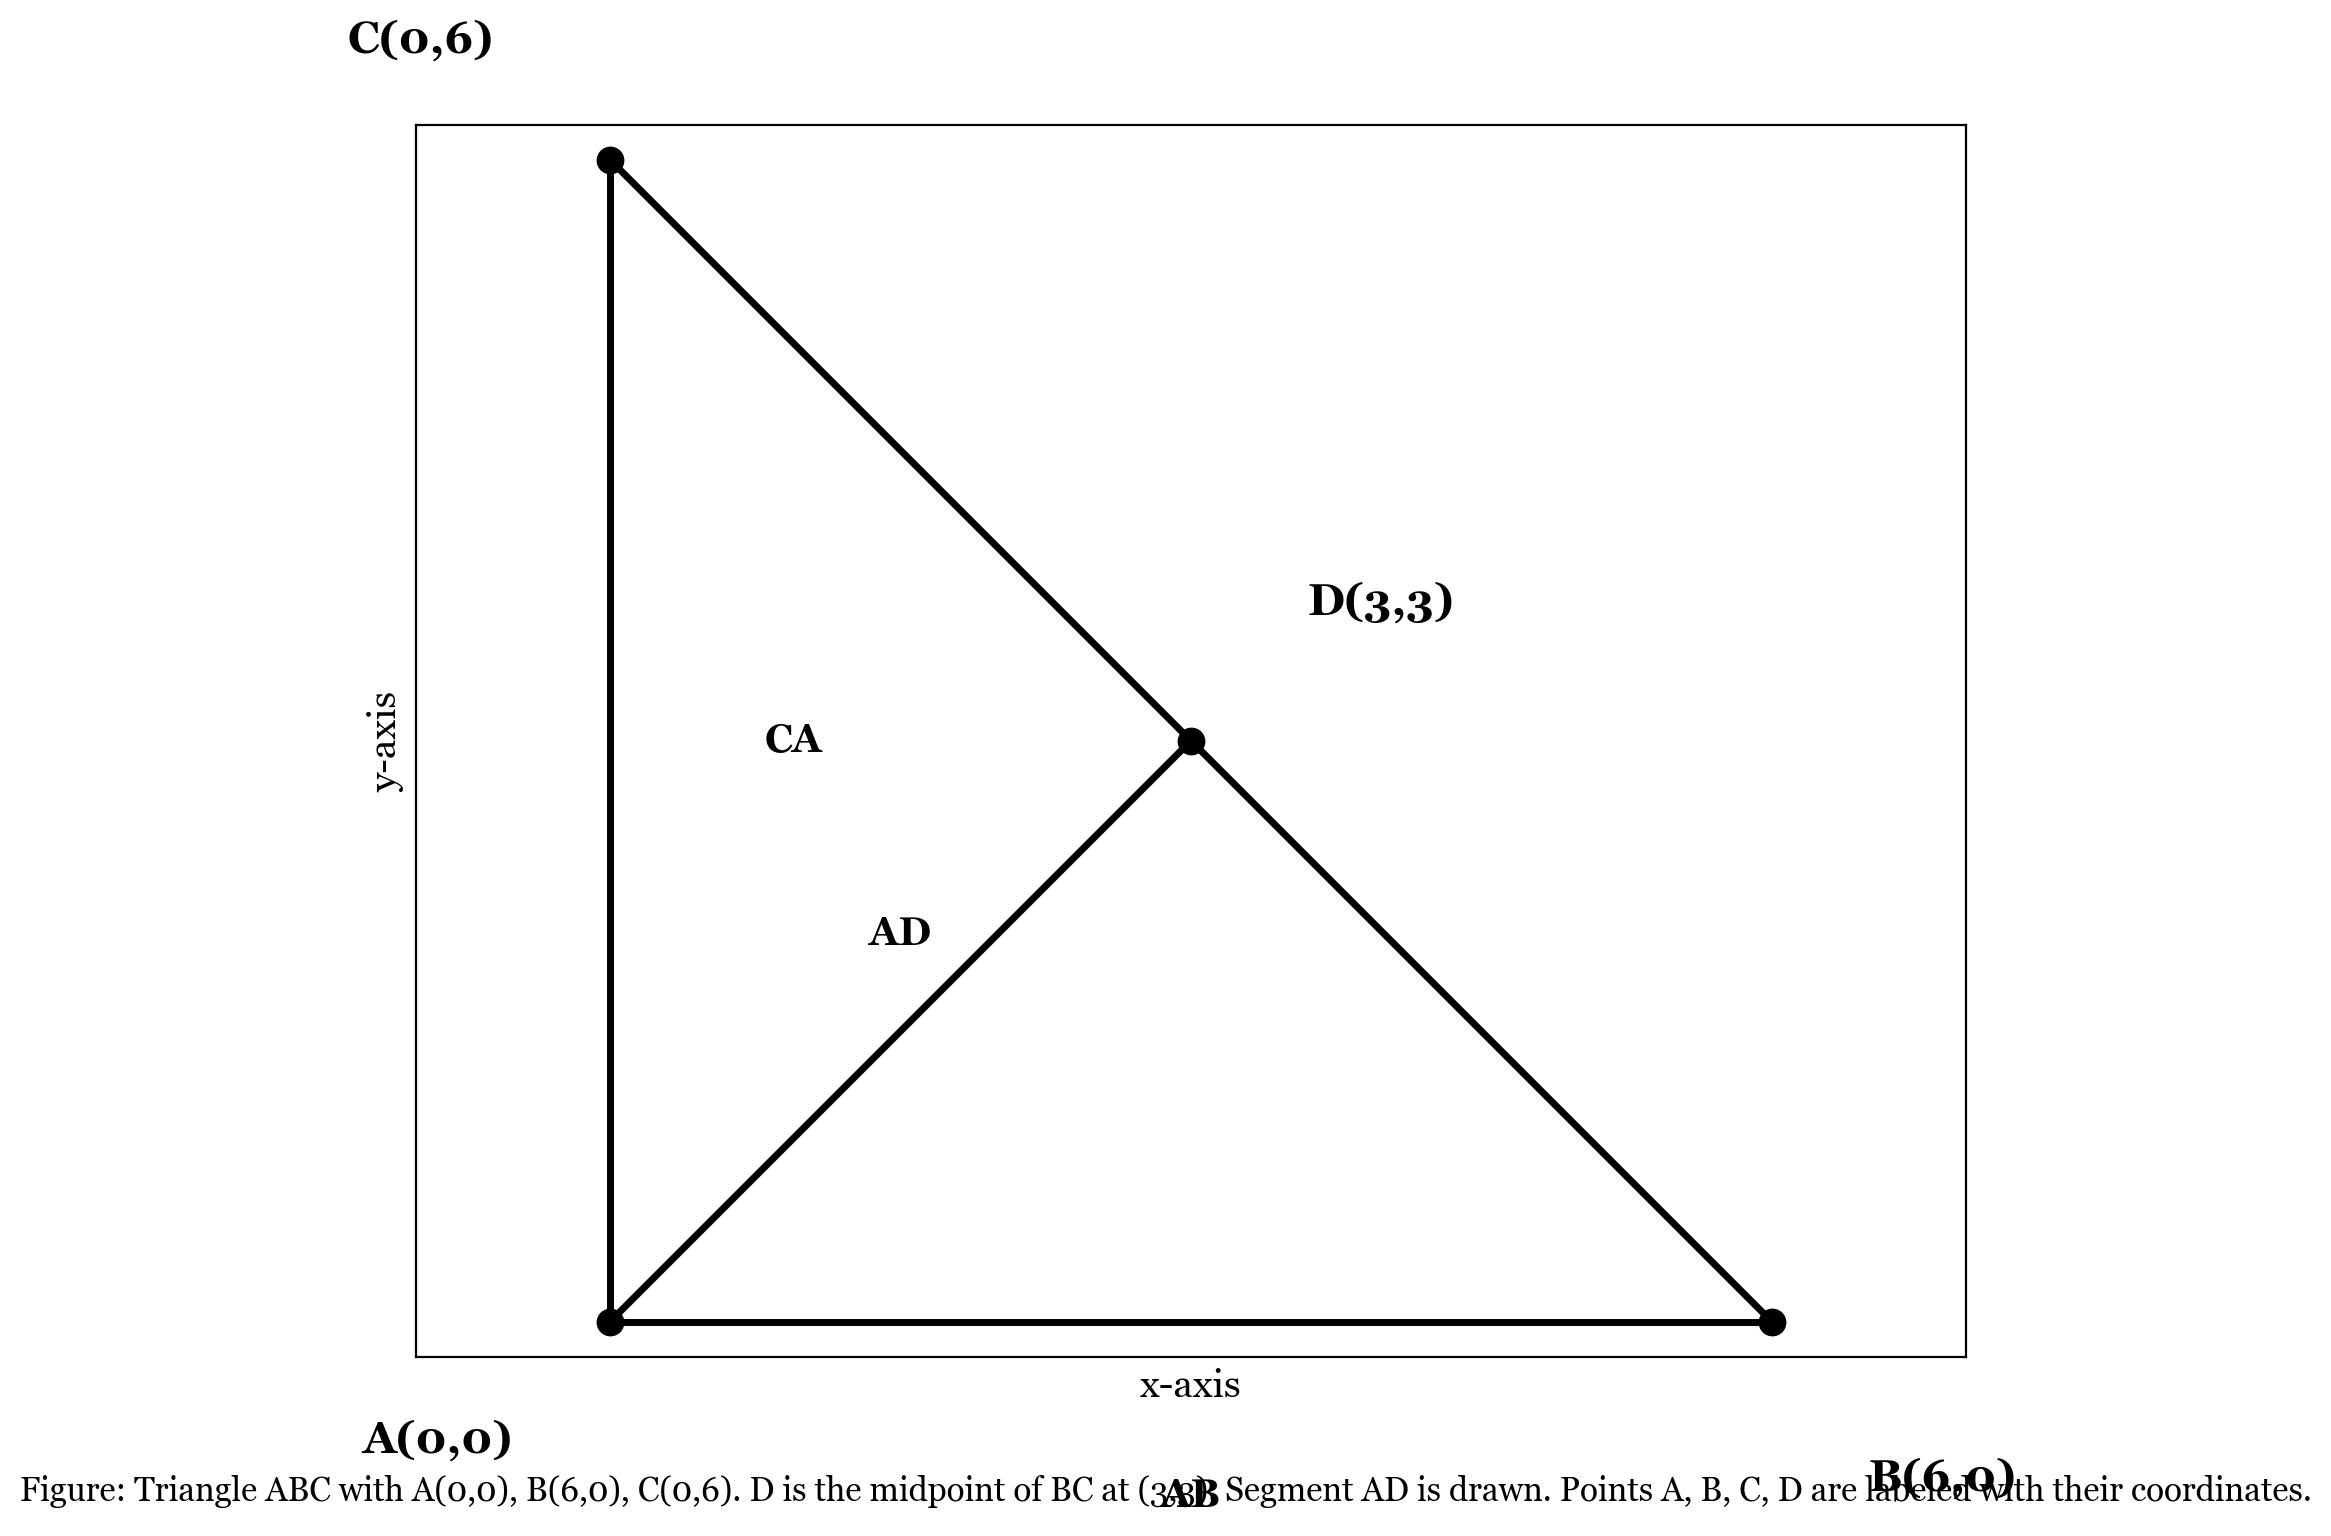

✓ Diagram displayed


In [150]:
# Display the rendered diagram
display(HTML(f'<img src="data:image/png;base64,{img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" />'))
print("✓ Diagram displayed")


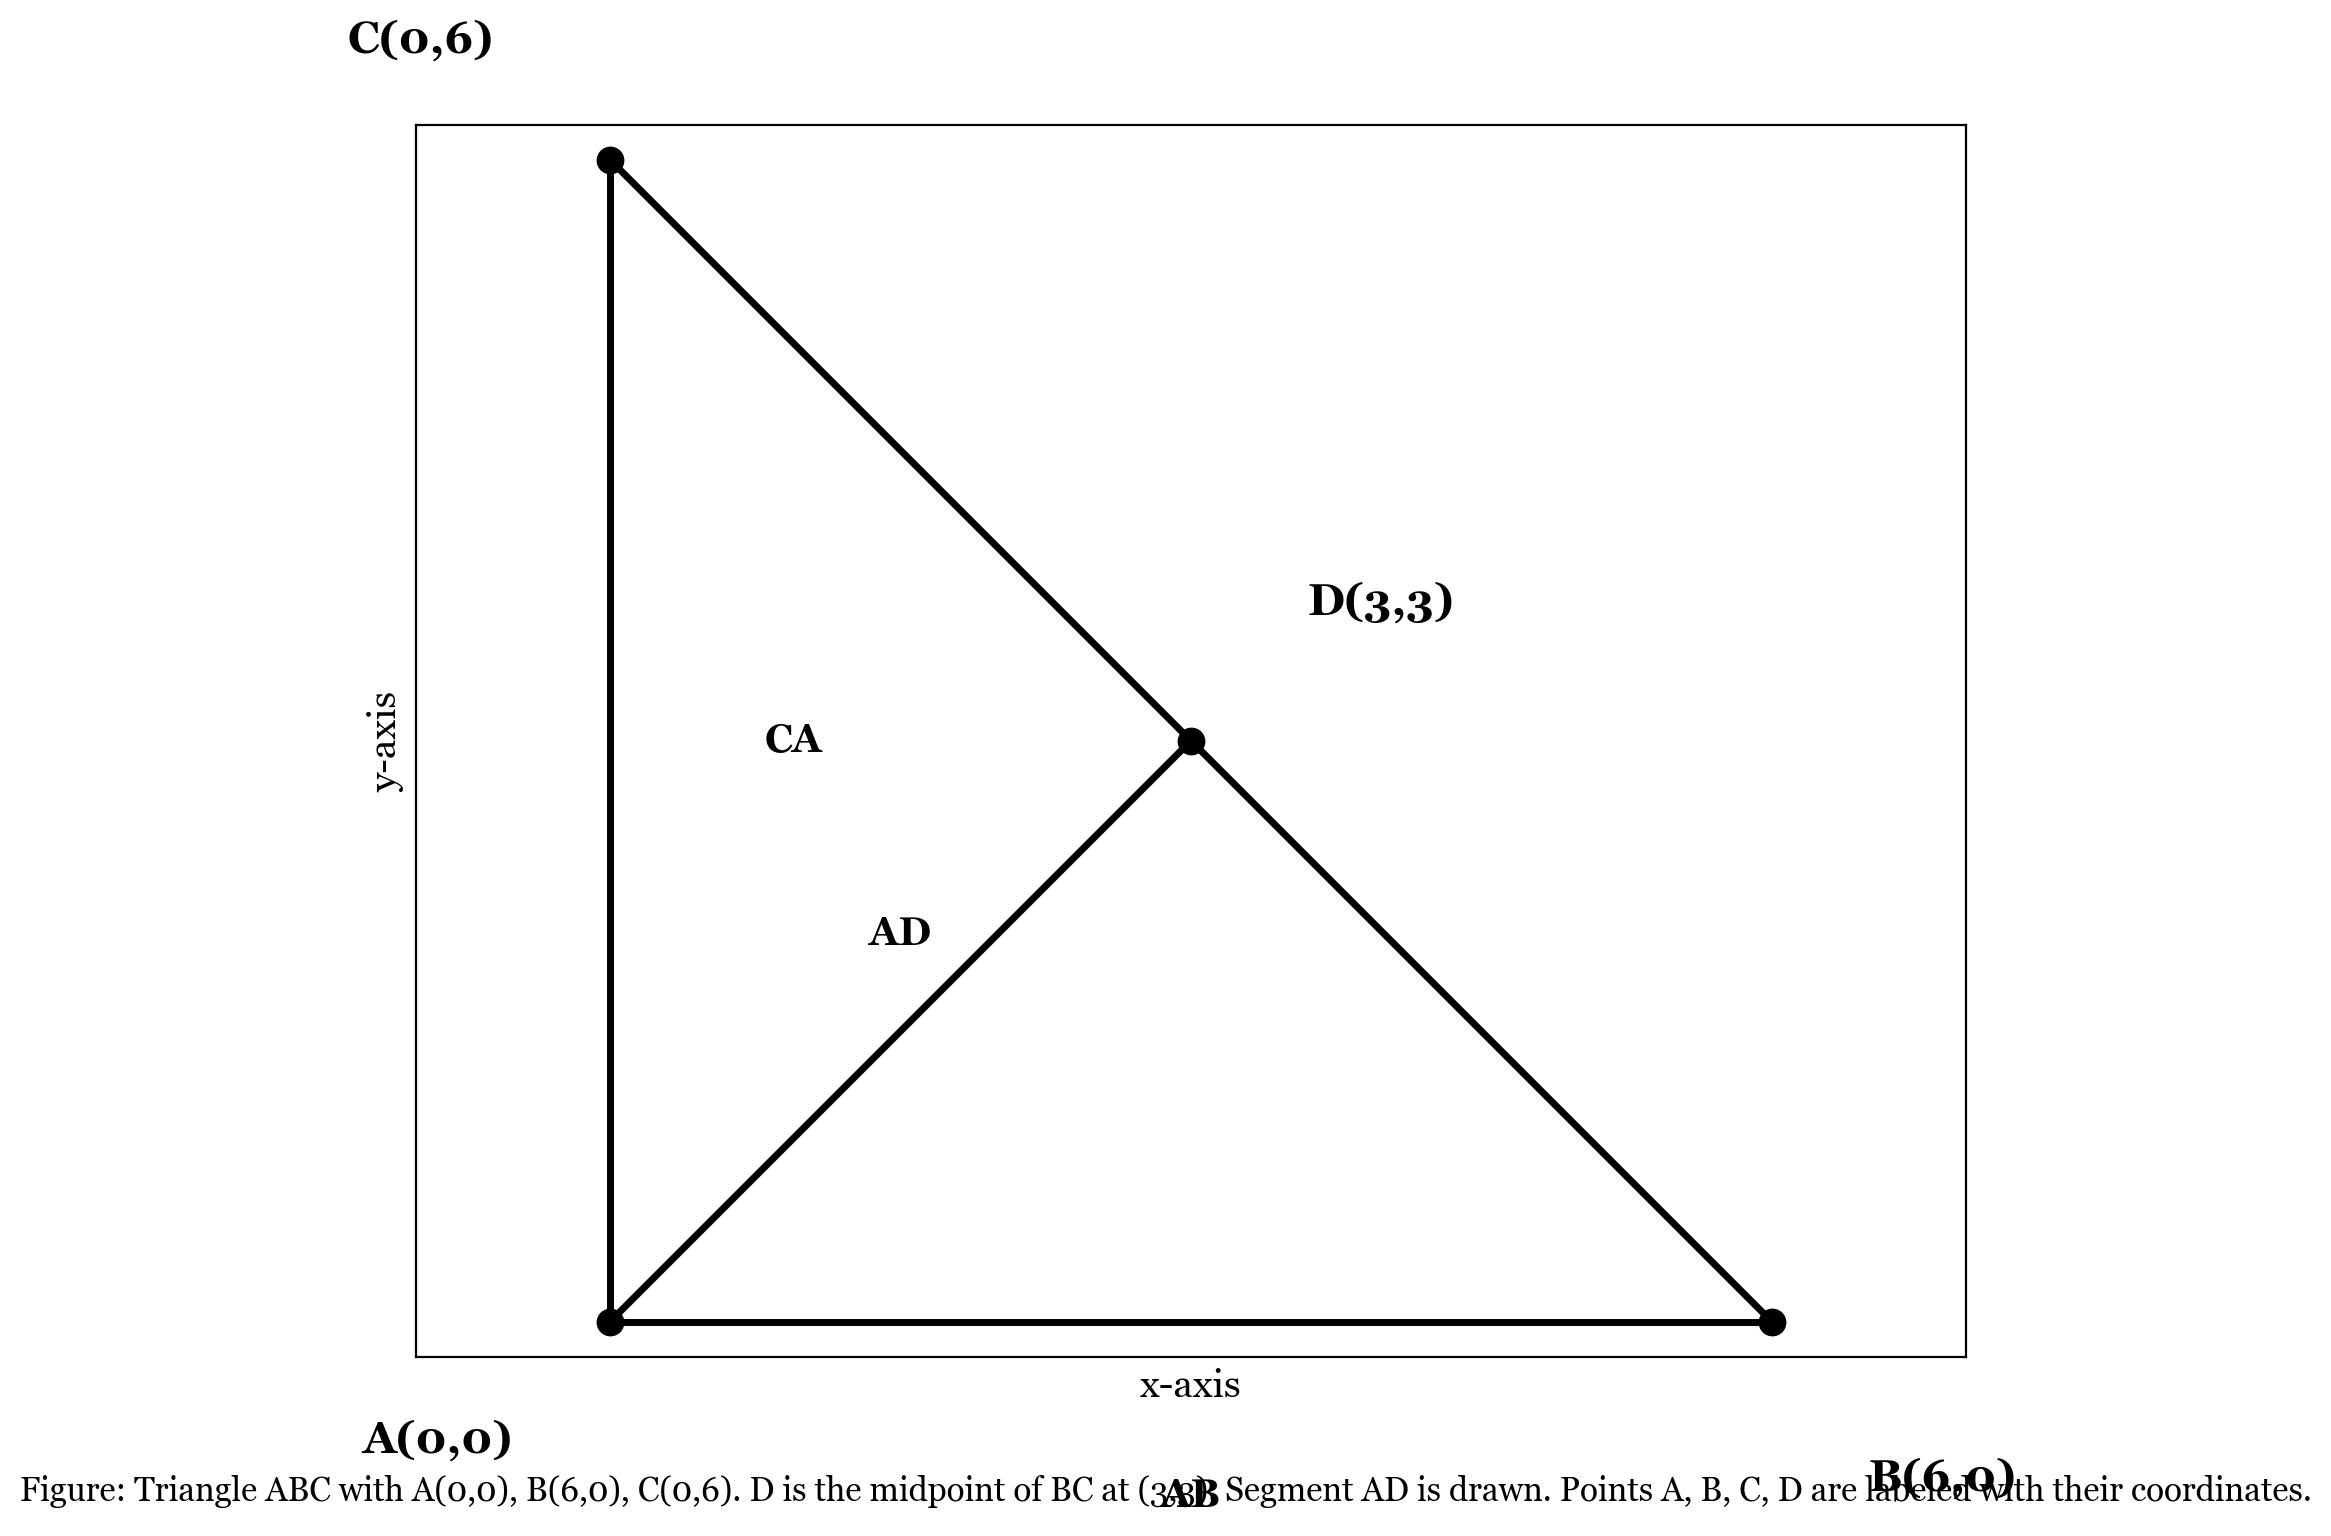

✓ SAT question displayed with diagram and choices


In [151]:
# Display the complete SAT question with diagram and choices
html_output = f"""
<div style="font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 2px solid #333; border-radius: 10px; background-color: #f9f9f9;">
    <h2 style="color: #2c3e50; text-align: center; margin-bottom: 20px;">SAT Math Question</h2>
    
    <div style="background-color: white; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
        <p style="font-size: 16px; line-height: 1.6; color: #333;"><strong>Question:</strong> {question_data['question']}</p>
    </div>
    
    <div style="text-align: center; margin: 20px 0; padding: 15px; background-color: white; border-radius: 5px;">
        <h3 style="color: #2c3e50; margin-bottom: 15px;">Diagram</h3>
        <img src="data:image/png;base64,{img_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px;" />
    </div>
    
    <div style="background-color: white; padding: 15px; border-radius: 5px;">
        <h3 style="color: #2c3e50; margin-bottom: 15px;">Answer Choices</h3>
        <ul style="list-style-type: none; padding: 0;">
            {"".join([f'<li style="padding: 10px; margin: 5px 0; background-color: #f0f0f0; border-radius: 3px; font-size: 15px;">{choice}</li>' for choice in question_data['choices']])}
        </ul>
    </div>
</div>
"""

display(HTML(html_output))
print("✓ SAT question displayed with diagram and choices")

In [152]:
# TECHNICAL VALIDATION: Check question-diagram consistency
print("Performing technical validation of question and diagram...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are a mathematical validation expert. Your job is to verify that geometry problems are mathematically sound and that diagrams accurately represent the problem."
    }, {
        "role": "user",
        "content": f"""Analyze this SAT math problem for technical correctness:

QUESTION:
{question_data['question']}

DIAGRAM DESCRIPTION:
{question_data['diagram_description']}

Perform the following validation checks:

1. GEOMETRIC VALIDITY:
   - If the question asks for area/perimeter/angle of a shape, do those points actually form that shape?
   - Are there any collinear points that should form a triangle? (This is INVALID)
   - Are all geometric relationships (parallel, perpendicular, tangent, etc.) possible?
   - Do all measurements and ratios make mathematical sense?

2. QUESTION-DIAGRAM MATCH:
   - Does every point, line, or shape mentioned in the question appear in the diagram description?
   - Does every label in the diagram correspond to something in the question?
   - Are coordinate values consistent between question and diagram?
   - Do the given measurements match what's shown?

3. SOLVABILITY:
   - Is there enough information to solve the problem?
   - Are there any contradictory constraints?
   - Is the problem well-defined?

4. TERMINOLOGY ACCURACY:
   - If it says "triangle DEF", do D, E, F actually form a triangle (non-collinear)?
   - If it says "circle", is there actually a circle?
   - Are geometric terms used correctly?

Return ONLY a JSON object:
{{
    "is_geometrically_valid": true or false,
    "is_question_diagram_match": true or false,
    "is_solvable": true or false,
    "is_terminology_correct": true or false,
    "critical_errors": ["list of any CRITICAL errors that make the problem unsolvable or incorrect"],
    "warnings": ["list of minor issues or ambiguities"],
    "validation_details": "detailed explanation of what you checked",
    "overall_status": "PASS, FAIL, or WARNING"
}}

Be VERY strict. If the question asks about "triangle DEF" but D, E, F are collinear (on the same line), this is a CRITICAL ERROR and FAIL."""
    }],
    response_format={"type": "json_object"}
)

technical_validation = json.loads(response.choices[0].message.content)
print("✓ Technical validation complete")

# Handle nested response format
if 'overall_status' not in technical_validation:
    print("⚠️ Parsing nested validation response...")
    if 'final' in technical_validation:
        if isinstance(technical_validation['final'], str):
            technical_validation = json.loads(technical_validation['final'])
        else:
            technical_validation = technical_validation['final']

if technical_validation.get('overall_status') == 'FAIL':
    print("⚠️ CRITICAL ERRORS FOUND - This question is INVALID")
    for error in technical_validation.get('critical_errors', []):
        print(f"  ❌ {error}")
elif technical_validation.get('overall_status') == 'WARNING':
    print("⚠️ Warnings found - Review needed")
    for warning in technical_validation.get('warnings', []):
        print(f"  ⚠️ {warning}")
else:
    print("✅ All validation checks passed")


Performing technical validation of question and diagram...
✓ Technical validation complete
✅ All validation checks passed


In [153]:
# Display technical validation results
overall_status = technical_validation.get('overall_status', 'UNKNOWN')
validation_color = "#2ecc71" if overall_status == "PASS" else ("#f39c12" if overall_status == "WARNING" else "#e74c3c")
validation_icon = "✅" if overall_status == "PASS" else ("⚠️" if overall_status == "WARNING" else "❌")

technical_validation_html = f"""
<div style="font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 3px solid {validation_color}; border-radius: 10px; background-color: {validation_color}15;">
    <h2 style="color: {validation_color}; text-align: center; margin-bottom: 20px;">{validation_icon} Technical Validation</h2>
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; margin-bottom: 15px;">
        <h3 style="color: #2c3e50; margin-top: 0;">🔍 Validation Checks</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px; font-weight: bold;">Geometric Validity</td>
                <td style="padding: 10px; text-align: right; color: {'#2ecc71' if technical_validation.get('is_geometrically_valid', False) else '#e74c3c'}; font-size: 24px;">
                    {'✓' if technical_validation.get('is_geometrically_valid', False) else '✗'}
                </td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px; font-weight: bold;">Question-Diagram Match</td>
                <td style="padding: 10px; text-align: right; color: {'#2ecc71' if technical_validation.get('is_question_diagram_match', False) else '#e74c3c'}; font-size: 24px;">
                    {'✓' if technical_validation.get('is_question_diagram_match', False) else '✗'}
                </td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px; font-weight: bold;">Solvability</td>
                <td style="padding: 10px; text-align: right; color: {'#2ecc71' if technical_validation.get('is_solvable', False) else '#e74c3c'}; font-size: 24px;">
                    {'✓' if technical_validation.get('is_solvable', False) else '✗'}
                </td>
            </tr>
            <tr>
                <td style="padding: 10px; font-weight: bold;">Terminology Accuracy</td>
                <td style="padding: 10px; text-align: right; color: {'#2ecc71' if technical_validation.get('is_terminology_correct', False) else '#e74c3c'}; font-size: 24px;">
                    {'✓' if technical_validation.get('is_terminology_correct', False) else '✗'}
                </td>
            </tr>
        </table>
    </div>
    
    {f'''<div style="background-color: #f8d7da; padding: 20px; border-radius: 5px; border-left: 5px solid #e74c3c; margin-bottom: 15px;">
        <h3 style="color: #721c24; margin-top: 0;">❌ CRITICAL ERRORS</h3>
        <ul style="color: #721c24; margin: 10px 0; line-height: 1.8;">
            {"".join([f"<li><strong>{error}</strong></li>" for error in technical_validation.get('critical_errors', [])])}
        </ul>
        <p style="color: #721c24; font-weight: bold; margin-top: 15px;">⚠️ This question CANNOT be used and must be regenerated.</p>
    </div>''' if technical_validation.get('critical_errors') else ''}
    
    {f'''<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px; border-left: 5px solid #f39c12; margin-bottom: 15px;">
        <h3 style="color: #856404; margin-top: 0;">⚠️ Warnings</h3>
        <ul style="color: #856404; margin: 10px 0; line-height: 1.6;">
            {"".join([f"<li>{warning}</li>" for warning in technical_validation.get('warnings', [])])}
        </ul>
    </div>''' if technical_validation.get('warnings') else ''}
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; margin-bottom: 15px;">
        <h3 style="color: #2c3e50; margin-top: 0;">📋 Validation Details</h3>
        <p style="font-size: 15px; line-height: 1.8; color: #333; white-space: pre-wrap;">{technical_validation.get('validation_details', 'No details available')}</p>
    </div>
    
    <div style="background-color: {validation_color}; padding: 20px; border-radius: 5px; text-align: center;">
        <h3 style="color: white; margin: 0; text-transform: uppercase; font-size: 24px;">
            OVERALL STATUS: {overall_status}
        </h3>
    </div>
</div>
"""

display(HTML(technical_validation_html))
print("✓ Technical validation results displayed")

# Stop execution if critical errors found
if technical_validation.get('overall_status') == 'FAIL':
    raise RuntimeError("CRITICAL VALIDATION FAILURE: The question contains mathematical errors and cannot be used. Please re-run cells 3-7 to generate a new question.")


Geometric Validity,✓
Question-Diagram Match,✓
Solvability,✓
Terminology Accuracy,✓


✓ Technical validation results displayed


In [154]:
# Generate explanation and answer
print("Generating explanation and answer...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert SAT math tutor. Provide clear, step-by-step explanations for geometry problems with proper mathematical notation."
    }, {
        "role": "user",
        "content": f"""Given this SAT math problem:

Question: {question_data['question']}

Answer choices:
{chr(10).join(question_data['choices'])}

Provide a complete solution with:
1. The correct answer (specify which choice: A, B, C, or D)
2. A detailed step-by-step explanation showing how to solve it
3. Any relevant formulas or theorems used

IMPORTANT: Format ALL mathematical expressions using LaTeX notation enclosed in $...$ for inline math or $$...$$ for display math.

CRITICAL: EVERY variable, number in equations, fractions, and mathematical symbols MUST be wrapped in $ signs.

Examples of CORRECT formatting:
- Variables: $x$, $y$, $AD$, $s$, $r$ (NOT just x or AD)
- Fractions: $\\frac{{{{24}}}}{{{{7}}}}$, $\\frac{{{{1}}}}{{{{2}}}}$ (ALWAYS use $ signs)
- Equations: $A = s^2$, $y = mx + b$ (NOT A = s^2 or y = mx + b)
- With parentheses: $\\left(\\frac{{{{24}}}}{{{{7}}}}\\right)^2$ (use \\left and \\right inside $ signs)
- Coordinates: $(x, y)$ or $F = \\left(\\frac{{{{40}}}}{{{{23}}}}, \\frac{{{{15}}}}{{{{23}}}}\\right)$
- Subscripts: $x_1$, $x_2$, $A_{{{{square}}}}$ (NOT x_1 or A_{{square}})
- Square roots: $\\sqrt{{{{x}}}}$, $\\sqrt{{{{2}}}}$
- Operations: $2 \\times 3$ or $2 \\cdot 3$

WRONG (will not render):
- A_{{square}} = s^2 = \\left(\\frac{{24}}{{7}}\\right)^2
- AD = 4.8

RIGHT (will render properly):
- $A_{{{{square}}}} = s^2 = \\left(\\frac{{{{24}}}}{{{{7}}}}\\right)^2$
- $AD = 4.8$

Return ONLY a JSON object with this structure:
{{
    "correct_answer": "A" or "B" or "C" or "D",
    "answer_value": "the actual numeric or algebraic value (use LaTeX if needed)",
    "explanation": "detailed step-by-step solution with clear reasoning using LaTeX for all math expressions"
}}"""
    }],
    response_format={"type": "json_object"}
)

solution_data = json.loads(response.choices[0].message.content)
print("✓ Solution generated")
print(f"Correct answer: {solution_data['correct_answer']}) {solution_data['answer_value']}")


Generating explanation and answer...
✓ Solution generated
Correct answer: B) $9$


In [155]:
# Display the solution with explanation using MathJax for LaTeX rendering
solution_html = f"""
<script src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/3.2.2/es5/tex-mml-chtml.min.js"></script>

<div style="font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 2px solid #2ecc71; border-radius: 10px; background-color: #f0fff4;">
    <h2 style="color: #27ae60; text-align: center; margin-bottom: 20px;">💡 Solution & Explanation</h2>
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; margin-bottom: 20px; border-left: 5px solid #2ecc71;">
        <h3 style="color: #27ae60; margin-top: 0;">✓ Correct Answer</h3>
        <p style="font-size: 24px; font-weight: bold; color: #27ae60; margin: 10px 0;" id="answer-display">
            {solution_data['correct_answer']}) {solution_data['answer_value']}
        </p>
    </div>
    
    <div style="background-color: white; padding: 20px; border-radius: 5px;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 Step-by-Step Explanation</h3>
        <div style="font-size: 16px; line-height: 2.0; color: #333; white-space: pre-line;">
{solution_data['explanation']}
        </div>
    </div>
</div>

<script>
    // Configure MathJax
    window.MathJax = {{
        tex: {{
            inlineMath: [['$', '$']],
            displayMath: [['$$', '$$']],
            processEscapes: true
        }},
        svg: {{
            fontCache: 'global'
        }}
    }};
    
    // Trigger MathJax rendering
    if (window.MathJax) {{
        MathJax.typesetPromise();
    }}
</script>
"""

display(HTML(solution_html))
print("✓ Solution displayed with LaTeX rendering")


✓ Solution displayed with LaTeX rendering


In [156]:
# Debug: Check explanation content
print("=== DEBUG: Explanation Content ===")
print(f"Answer value: {solution_data['answer_value']}")
print(f"\nFirst 600 chars of explanation:")
print(solution_data['explanation'][:600])
print("\n=== END DEBUG ===")

=== DEBUG: Explanation Content ===
Answer value: $9$

First 600 chars of explanation:
Step 1. Find the coordinates of point $D$ as the midpoint of $B$ and $C$. Since $B=(6,0)$ and $C=(0,6)$, $D=\left(\frac{6+0}{2}, \frac{0+6}{2}\right)=(3,3)$.\nStep 2. Treat $AB$ as the base. The segment $AB$ lies on the line $y=0$ with length $|AB|=6$. The height from $D$ to $AB$ is the distance from $D$ to $y=0$, which is $|y_D|=3$.\nStep 3. Compute area using base and height: $\text{Area}_{ABD}=\frac{1}{2}\cdot |AB|\cdot \text{height}=\frac{1}{2}\cdot 6\cdot 3=9$.\nAlternative check: using vectors, $\vec{AB}=(6,0)$ and $\vec{AD}=(3,3)$, and $\text{Area}_{ABD}=\frac{1}{2}|\vec{AB}\times \vec{

=== END DEBUG ===


In [157]:
# Verify the question quality and answer correctness
print("Verifying question quality and solution correctness...")

response = client.chat.completions.create(
    model=deployment_name,
    messages=[{
        "role": "system",
        "content": "You are an expert SAT question reviewer. Your job is to verify that SAT math questions are well-formed, solvable, and have correct answers."
    }, {
        "role": "user",
        "content": f"""Review this SAT math question and its proposed solution:

QUESTION:
{question_data['question']}

ANSWER CHOICES:
{chr(10).join(question_data['choices'])}

PROPOSED SOLUTION:
Correct answer: {solution_data['correct_answer']}) {solution_data['answer_value']}

Explanation:
{solution_data['explanation']}

Verify the following and return a JSON object:

1. Is the question clear and well-written?
2. Is the question solvable with the given information?
3. Is the proposed answer mathematically correct?
4. Do all answer choices make sense?
5. Are there any errors or inconsistencies?

Return ONLY a JSON object with this structure:
{{
    "is_valid": true or false,
    "is_answer_correct": true or false,
    "quality_score": 1-10,
    "issues_found": ["list of any issues or errors found"],
    "verification_notes": "detailed explanation of your verification",
    "recommendation": "approve, revise, or reject"
}}"""
    }],
    response_format={"type": "json_object"}
)

verification_data = json.loads(response.choices[0].message.content)
print("✓ Verification complete")
print(f"Quality Score: {verification_data['quality_score']}/10")
print(f"Answer Correct: {'✓ Yes' if verification_data['is_answer_correct'] else '✗ No'}")
print(f"Recommendation: {verification_data['recommendation'].upper()}")

Verifying question quality and solution correctness...
✓ Verification complete
Quality Score: 9/10
Answer Correct: ✓ Yes
Recommendation: APPROVE


In [158]:
# Display verification results
verification_color = "#2ecc71" if verification_data['recommendation'] == "approve" else ("#f39c12" if verification_data['recommendation'] == "revise" else "#e74c3c")
verification_icon = "✓" if verification_data['recommendation'] == "approve" else ("⚠️" if verification_data['recommendation'] == "revise" else "✗")

verification_html = f"""
<div style="font-family: Arial, sans-serif; max-width: 800px; margin: 20px auto; padding: 20px; border: 2px solid {verification_color}; border-radius: 10px; background-color: {verification_color}15;">
    <h2 style="color: {verification_color}; text-align: center; margin-bottom: 20px;">{verification_icon} Quality Verification</h2>
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; margin-bottom: 15px;">
        <h3 style="color: #2c3e50; margin-top: 0;">📊 Scores</h3>
        <div style="display: flex; justify-content: space-around; margin: 15px 0;">
            <div style="text-align: center;">
                <div style="font-size: 36px; font-weight: bold; color: {verification_color};">
                    {verification_data['quality_score']}/10
                </div>
                <div style="color: #666; font-size: 14px;">Quality Score</div>
            </div>
            <div style="text-align: center;">
                <div style="font-size: 36px; font-weight: bold; color: {'#2ecc71' if verification_data['is_answer_correct'] else '#e74c3c'};">
                    {'✓' if verification_data['is_answer_correct'] else '✗'}
                </div>
                <div style="color: #666; font-size: 14px;">Answer Correctness</div>
            </div>
            <div style="text-align: center;">
                <div style="font-size: 36px; font-weight: bold; color: {'#2ecc71' if verification_data['is_valid'] else '#e74c3c'};">
                    {'✓' if verification_data['is_valid'] else '✗'}
                </div>
                <div style="color: #666; font-size: 14px;">Question Valid</div>
            </div>
        </div>
    </div>
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; margin-bottom: 15px;">
        <h3 style="color: #2c3e50; margin-top: 0;">🔍 Verification Notes</h3>
        <p style="font-size: 15px; line-height: 1.6; color: #333; white-space: pre-wrap;">{verification_data['verification_notes']}</p>
    </div>
    
    {f'''<div style="background-color: #fff3cd; padding: 15px; border-radius: 5px; border-left: 5px solid #f39c12; margin-bottom: 15px;">
        <h3 style="color: #856404; margin-top: 0;">⚠️ Issues Found</h3>
        <ul style="color: #856404; margin: 10px 0;">
            {"".join([f"<li>{issue}</li>" for issue in verification_data['issues_found']])}
        </ul>
    </div>''' if verification_data['issues_found'] else ''}
    
    <div style="background-color: white; padding: 20px; border-radius: 5px; text-align: center;">
        <h3 style="color: {verification_color}; margin-top: 0; text-transform: uppercase;">
            Recommendation: {verification_data['recommendation']}
        </h3>
    </div>
</div>
"""

display(HTML(verification_html))
print("✓ Verification results displayed")

✓ Verification results displayed


In [159]:
# Save all outputs to files with timestamp
import datetime

# Create timestamp for unique filenames
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Saving outputs with timestamp: {timestamp}")

# 1. Save diagram image
diagram_filename = f"sat_diagram_{timestamp}.png"
with open(diagram_filename, 'wb') as f:
    f.write(base64.b64decode(img_base64))
print(f"✓ Diagram saved to {diagram_filename}")

# 2. Save complete question data as JSON
question_filename = f"sat_question_{timestamp}.json"
question_export = {
    "timestamp": timestamp,
    "question": question_data['question'],
    "choices": question_data['choices'],
    "diagram_description": question_data['diagram_description'],
    "correct_answer": solution_data['correct_answer'],
    "answer_value": solution_data['answer_value'],
    "explanation": solution_data['explanation']
}
with open(question_filename, 'w', encoding='utf-8') as f:
    json.dump(question_export, f, indent=2, ensure_ascii=False)
print(f"✓ Question data saved to {question_filename}")

# 3. Save technical validation results
validation_filename = f"sat_validation_{timestamp}.json"
with open(validation_filename, 'w', encoding='utf-8') as f:
    json.dump(technical_validation, f, indent=2, ensure_ascii=False)
print(f"✓ Technical validation saved to {validation_filename}")

# 4. Save quality verification results
verification_filename = f"sat_verification_{timestamp}.json"
with open(verification_filename, 'w', encoding='utf-8') as f:
    json.dump(verification_data, f, indent=2, ensure_ascii=False)
print(f"✓ Quality verification saved to {verification_filename}")

# 5. Save human-readable summary
summary_filename = f"sat_summary_{timestamp}.txt"
with open(summary_filename, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("SAT MATH QUESTION - COMPLETE SUMMARY\n")
    f.write(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*70 + "\n\n")
    
    f.write("QUESTION:\n")
    f.write("-" * 70 + "\n")
    f.write(f"{question_data['question']}\n\n")
    
    f.write("ANSWER CHOICES:\n")
    f.write("-" * 70 + "\n")
    for choice in question_data['choices']:
        f.write(f"{choice}\n")
    f.write("\n")
    
    f.write("CORRECT ANSWER:\n")
    f.write("-" * 70 + "\n")
    f.write(f"{solution_data['correct_answer']}) {solution_data['answer_value']}\n\n")
    
    f.write("EXPLANATION:\n")
    f.write("-" * 70 + "\n")
    f.write(f"{solution_data['explanation']}\n\n")
    
    f.write("TECHNICAL VALIDATION:\n")
    f.write("-" * 70 + "\n")
    f.write(f"Overall Status: {technical_validation.get('overall_status', 'N/A')}\n")
    f.write(f"Geometrically Valid: {technical_validation.get('is_geometrically_valid', 'N/A')}\n")
    f.write(f"Question-Diagram Match: {technical_validation.get('is_question_diagram_match', 'N/A')}\n")
    f.write(f"Solvable: {technical_validation.get('is_solvable', 'N/A')}\n")
    f.write(f"Terminology Correct: {technical_validation.get('is_terminology_correct', 'N/A')}\n")
    if technical_validation.get('critical_errors'):
        f.write(f"\nCritical Errors: {', '.join(technical_validation['critical_errors'])}\n")
    if technical_validation.get('warnings'):
        f.write(f"Warnings: {', '.join(technical_validation['warnings'])}\n")
    f.write("\n")
    
    f.write("QUALITY VERIFICATION:\n")
    f.write("-" * 70 + "\n")
    f.write(f"Quality Score: {verification_data['quality_score']}/10\n")
    f.write(f"Answer Correct: {verification_data['is_answer_correct']}\n")
    f.write(f"Recommendation: {verification_data['recommendation'].upper()}\n")
    if verification_data.get('issues_found'):
        f.write(f"\nIssues Found: {', '.join(verification_data['issues_found'])}\n")
    f.write("\n")
    
    f.write("FILES GENERATED:\n")
    f.write("-" * 70 + "\n")
    f.write(f"- {diagram_filename} (diagram image)\n")
    f.write(f"- {question_filename} (complete question data)\n")
    f.write(f"- {validation_filename} (technical validation)\n")
    f.write(f"- {verification_filename} (quality verification)\n")
    f.write(f"- {summary_filename} (this summary)\n")

print(f"✓ Summary saved to {summary_filename}")

print("\n" + "="*70)
print("📁 ALL FILES SAVED SUCCESSFULLY!")
print("="*70)
print(f"Files saved with timestamp: {timestamp}")
print(f"- Diagram: {diagram_filename}")
print(f"- Question JSON: {question_filename}")
print(f"- Validation: {validation_filename}")
print(f"- Verification: {verification_filename}")
print(f"- Summary: {summary_filename}")
print(f"- HTML Page: (see next cell)")

Saving outputs with timestamp: 20260126_092843
✓ Diagram saved to sat_diagram_20260126_092843.png
✓ Question data saved to sat_question_20260126_092843.json
✓ Technical validation saved to sat_validation_20260126_092843.json
✓ Quality verification saved to sat_verification_20260126_092843.json
✓ Summary saved to sat_summary_20260126_092843.txt

📁 ALL FILES SAVED SUCCESSFULLY!
Files saved with timestamp: 20260126_092843
- Diagram: sat_diagram_20260126_092843.png
- Question JSON: sat_question_20260126_092843.json
- Validation: sat_validation_20260126_092843.json
- Verification: sat_verification_20260126_092843.json
- Summary: sat_summary_20260126_092843.txt
- HTML Page: (see next cell)


In [160]:
# Save complete HTML page for viewing
html_page_filename = f"sat_complete_{timestamp}.html"

# Calculate total time taken
end_time = time.time()
total_time_seconds = end_time - start_time
total_time_minutes = total_time_seconds / 60

# Build complete HTML page
complete_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>SAT Math Question - {timestamp}</title>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/3.2.2/es5/tex-mml-chtml.min.js"></script>
    <style>
        body {{
            font-family: Arial, sans-serif;
            max-width: 1000px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 30px;
            border-radius: 10px;
            text-align: center;
            margin-bottom: 30px;
        }}
        .section {{
            background-color: white;
            padding: 25px;
            margin-bottom: 20px;
            border-radius: 10px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }}
        .section h2 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
            margin-top: 0;
        }}
        .question-text {{
            font-size: 18px;
            line-height: 1.8;
            color: #333;
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 5px;
            border-left: 5px solid #3498db;
        }}
        .choices {{
            list-style-type: none;
            padding: 0;
        }}
        .choices li {{
            padding: 12px;
            margin: 8px 0;
            background-color: #f0f0f0;
            border-radius: 5px;
            font-size: 16px;
        }}
        .correct-answer {{
            background-color: #d4edda !important;
            border-left: 5px solid #28a745;
            font-weight: bold;
        }}
        .diagram-container {{
            text-align: center;
            padding: 20px;
            background-color: #f8f9fa;
            border-radius: 5px;
        }}
        .diagram-container img {{
            max-width: 100%;
            border: 2px solid #ddd;
            border-radius: 5px;
        }}
        .explanation {{
            font-size: 16px;
            line-height: 2.0;
            color: #333;
            background-color: #f0fff4;
            padding: 20px;
            border-radius: 5px;
            border-left: 5px solid #2ecc71;
            white-space: pre-line;
        }}
        .validation-grid {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
            margin: 20px 0;
        }}
        .validation-item {{
            padding: 15px;
            border-radius: 5px;
            text-align: center;
        }}
        .validation-pass {{
            background-color: #d4edda;
            border: 2px solid #28a745;
        }}
        .validation-fail {{
            background-color: #f8d7da;
            border: 2px solid #dc3545;
        }}
        .validation-item h3 {{
            margin: 0 0 10px 0;
            font-size: 16px;
        }}
        .validation-item .icon {{
            font-size: 36px;
        }}
        .score-box {{
            display: inline-block;
            padding: 20px 40px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            border-radius: 10px;
            font-size: 32px;
            font-weight: bold;
            margin: 20px 0;
        }}
        .status-badge {{
            display: inline-block;
            padding: 10px 20px;
            border-radius: 20px;
            font-weight: bold;
            font-size: 18px;
            text-transform: uppercase;
        }}
        .status-pass {{
            background-color: #28a745;
            color: white;
        }}
        .status-warning {{
            background-color: #ffc107;
            color: black;
        }}
        .status-fail {{
            background-color: #dc3545;
            color: white;
        }}
        .timestamp {{
            color: #888;
            font-size: 14px;
            text-align: center;
            margin-top: 30px;
        }}
        .alert {{
            padding: 15px;
            border-radius: 5px;
            margin: 15px 0;
        }}
        .alert-danger {{
            background-color: #f8d7da;
            border-left: 5px solid #dc3545;
            color: #721c24;
        }}
        .alert-warning {{
            background-color: #fff3cd;
            border-left: 5px solid #ffc107;
            color: #856404;
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>📐 SAT Math Question</h1>
        <p>Generated: {datetime.datetime.now().strftime('%B %d, %Y at %I:%M %p')}</p>
        <p style="font-size: 14px; margin-top: 10px;">⏱️ Total Generation Time: {total_time_minutes:.2f} minutes ({total_time_seconds:.1f} seconds)</p>
    </div>

    <!-- Question Section -->
    <div class="section">
        <h2>📝 Question</h2>
        <div class="question-text">
            {question_data['question']}
        </div>
    </div>

    <!-- Diagram Section -->
    <div class="section">
        <h2>📊 Diagram</h2>
        <div class="diagram-container">
            <img src="data:image/png;base64,{img_base64}" alt="Diagram">
        </div>
    </div>

    <!-- Answer Choices Section -->
    <div class="section">
        <h2>🔢 Answer Choices</h2>
        <ul class="choices">
            {"".join([f'<li class="{"correct-answer" if choice.startswith(solution_data["correct_answer"] + ")") else ""}">{choice} {"✓ CORRECT" if choice.startswith(solution_data["correct_answer"] + ")") else ""}</li>' for choice in question_data['choices']])}
        </ul>
    </div>

    <!-- Solution Section -->
    <div class="section">
        <h2>💡 Solution</h2>
        <div style="text-align: center; margin: 20px 0;">
            <div class="score-box">
                Answer: <span id="answer-value">{solution_data['correct_answer']}) {solution_data['answer_value']}</span>
            </div>
        </div>
        <h3 style="color: #2c3e50; margin-top: 30px;">Step-by-Step Explanation:</h3>
        <div class="explanation">
{solution_data['explanation']}
        </div>
    </div>

    <!-- Technical Validation Section -->
    <div class="section">
        <h2>🔍 Technical Validation</h2>
        <div style="text-align: center; margin: 20px 0;">
            <span class="status-badge status-{technical_validation.get('overall_status', 'unknown').lower()}">
                {technical_validation.get('overall_status', 'UNKNOWN')}
            </span>
        </div>
        
        <div class="validation-grid">
            <div class="validation-item {'validation-pass' if technical_validation.get('is_geometrically_valid', False) else 'validation-fail'}">
                <h3>Geometric Validity</h3>
                <div class="icon">{'✓' if technical_validation.get('is_geometrically_valid', False) else '✗'}</div>
            </div>
            <div class="validation-item {'validation-pass' if technical_validation.get('is_question_diagram_match', False) else 'validation-fail'}">
                <h3>Question-Diagram Match</h3>
                <div class="icon">{'✓' if technical_validation.get('is_question_diagram_match', False) else '✗'}</div>
            </div>
            <div class="validation-item {'validation-pass' if technical_validation.get('is_solvable', False) else 'validation-fail'}">
                <h3>Solvability</h3>
                <div class="icon">{'✓' if technical_validation.get('is_solvable', False) else '✗'}</div>
            </div>
            <div class="validation-item {'validation-pass' if technical_validation.get('is_terminology_correct', False) else 'validation-fail'}">
                <h3>Terminology Accuracy</h3>
                <div class="icon">{'✓' if technical_validation.get('is_terminology_correct', False) else '✗'}</div>
            </div>
        </div>

        {f'''<div class="alert alert-danger">
            <h3 style="margin-top: 0;">❌ Critical Errors</h3>
            <ul>
                {"".join([f"<li><strong>{error}</strong></li>" for error in technical_validation.get('critical_errors', [])])}
            </ul>
        </div>''' if technical_validation.get('critical_errors') else ''}

        {f'''<div class="alert alert-warning">
            <h3 style="margin-top: 0;">⚠️ Warnings</h3>
            <ul>
                {"".join([f"<li>{warning}</li>" for warning in technical_validation.get('warnings', [])])}
            </ul>
        </div>''' if technical_validation.get('warnings') else ''}

        <h3 style="color: #2c3e50; margin-top: 20px;">Validation Details:</h3>
        <p style="line-height: 1.6; color: #555; white-space: pre-wrap;">{technical_validation.get('validation_details', 'No details available')}</p>
    </div>

    <!-- Quality Verification Section -->
    <div class="section">
        <h2>⭐ Quality Verification</h2>
        
        <div style="text-align: center; margin: 30px 0;">
            <div class="score-box">
                Quality Score: {verification_data['quality_score']}/10
            </div>
        </div>

        <div class="validation-grid">
            <div class="validation-item {'validation-pass' if verification_data['is_valid'] else 'validation-fail'}">
                <h3>Question Valid</h3>
                <div class="icon">{'✓' if verification_data['is_valid'] else '✗'}</div>
            </div>
            <div class="validation-item {'validation-pass' if verification_data['is_answer_correct'] else 'validation-fail'}">
                <h3>Answer Correct</h3>
                <div class="icon">{'✓' if verification_data['is_answer_correct'] else '✗'}</div>
            </div>
        </div>

        <h3 style="color: #2c3e50; margin-top: 20px;">Verification Notes:</h3>
        <p style="line-height: 1.6; color: #555; white-space: pre-wrap;">{verification_data.get('verification_notes', 'No notes available')}</p>

        {f'''<div class="alert alert-warning">
            <h3 style="margin-top: 0;">Issues Found:</h3>
            <ul>
                {"".join([f"<li>{issue}</li>" for issue in verification_data.get('issues_found', [])])}
            </ul>
        </div>''' if verification_data.get('issues_found') else ''}

        <div style="text-align: center; margin-top: 30px;">
            <span class="status-badge status-{'pass' if verification_data['recommendation'] == 'approve' else ('warning' if verification_data['recommendation'] == 'revise' else 'fail')}">
                Recommendation: {verification_data['recommendation'].upper()}
            </span>
        </div>
    </div>

    <div class="timestamp">
        <p>Document ID: {timestamp}</p>
        <p>Total Generation Time: {total_time_minutes:.2f} minutes ({total_time_seconds:.1f} seconds)</p>
        <p>Generated by SAT Question Generator</p>
    </div>

    <script>
        // Configure MathJax before it loads
        window.MathJax = {{
            tex: {{
                inlineMath: [['$', '$']],
                displayMath: [['$$', '$$']],
                processEscapes: true,
                processEnvironments: true
            }},
            startup: {{
                typeset: false  // Don't typeset on startup
            }},
            svg: {{
                fontCache: 'global'
            }}
        }};
        
        // Trigger MathJax rendering after page and MathJax load
        window.addEventListener('load', function() {{
            // Wait for MathJax to be ready
            if (window.MathJax) {{
                MathJax.startup.promise.then(function() {{
                    // Process all math on the page
                    MathJax.typesetPromise().then(function() {{
                        console.log('MathJax rendering complete');
                    }}).catch(function(err) {{
                        console.error('MathJax typesetting error:', err);
                    }});
                }});
            }}
        }});
    </script>
</body>
</html>
"""

# Save the HTML file
with open(html_page_filename, 'w', encoding='utf-8') as f:
    f.write(complete_html)

print(f"✓ Complete HTML page saved to {html_page_filename}")
print(f"\n⏱️ Total generation time: {total_time_minutes:.2f} minutes ({total_time_seconds:.1f} seconds)")
print(f"📄 You can open {html_page_filename} in any web browser to view the complete question with all details!")


✓ Complete HTML page saved to sat_complete_20260126_092843.html

⏱️ Total generation time: 2.76 minutes (165.5 seconds)
📄 You can open sat_complete_20260126_092843.html in any web browser to view the complete question with all details!


## Quick Check

If you can't see the outputs above, run this cell to verify everything is working:

In [161]:
# Verify the notebook state and data
print("✓ Notebook is working correctly!")
print(f"\nQuestion generated: {len(question_data['question'])} characters")
print(f"Diagram image size: {len(img_base64)} bytes (base64)")
print(f"Answer choices: {len(question_data['choices'])} options")
print(f"\nFirst 200 chars of question:\n{question_data['question'][:200]}...")
print(f"\nAnswer choices:")
for choice in question_data['choices']:
    print(f"  {choice}")

✓ Notebook is working correctly!

Question generated: 134 characters
Diagram image size: 126464 bytes (base64)
Answer choices: 4 options

First 200 chars of question:
In the diagram, triangle ABC has vertices A(0,0), B(6,0), and C(0,6). Point D is the midpoint of BC. What is the area of triangle ABD?...

Answer choices:
  A) 6
  B) 9
  C) 12
  D) 18


In [162]:
# Save diagram to file for viewing
with open('sat_diagram.png', 'wb') as f:
    f.write(base64.b64decode(img_base64))
print("✓ Diagram saved to sat_diagram.png")

# Also save the question
with open('sat_question.txt', 'w', encoding='utf-8') as f:
    f.write("SAT MATH QUESTION\n")
    f.write("="*60 + "\n\n")
    f.write(f"QUESTION:\n{question_data['question']}\n\n")
    f.write("ANSWER CHOICES:\n")
    for choice in question_data['choices']:
        f.write(f"  {choice}\n")
print("✓ Question saved to sat_question.txt")

✓ Diagram saved to sat_diagram.png
✓ Question saved to sat_question.txt
